In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from IPython.display import display

In [2]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/AIML_Evaluation/Data/student_depression_balanced.csv")

In [4]:
# Separate features and target
X = df.drop("Depression", axis=1)
y = df["Depression"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")
print("-" * 70)

Training set: (25387, 10), Testing set: (6347, 10)
----------------------------------------------------------------------


In [5]:
# Handle class imbalance
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_factor = negative_count / positive_count
print(f"Class Imbalance Ratio (approx.): {scale_factor:.2f}")
print("-" * 70)

Class Imbalance Ratio (approx.): 1.00
----------------------------------------------------------------------



=== Training: Model 1 (Baseline) ===
Accuracy : 0.7816 | Precision: 0.7595 | Recall: 0.8241 | F1-Score: 0.7905 | AUC: 0.8448
Confusion Matrix:
[[2346  828]
 [ 558 2615]]


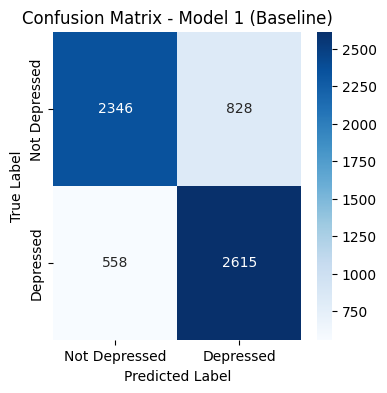


=== Training: Model 2 (L1 Regularization) ===
Accuracy : 0.7818 | Precision: 0.7596 | Recall: 0.8245 | F1-Score: 0.7907 | AUC: 0.8448
Confusion Matrix:
[[2346  828]
 [ 557 2616]]


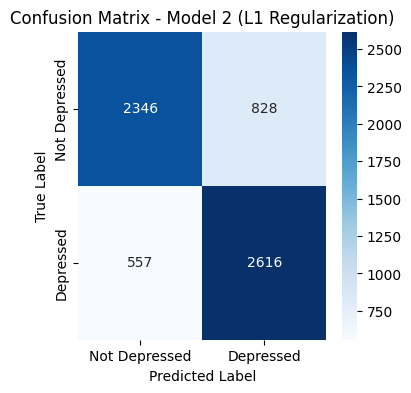


=== Training: Model 3 (L2 Balanced) ===
Accuracy : 0.7818 | Precision: 0.7597 | Recall: 0.8241 | F1-Score: 0.7906 | AUC: 0.8448
Confusion Matrix:
[[2347  827]
 [ 558 2615]]


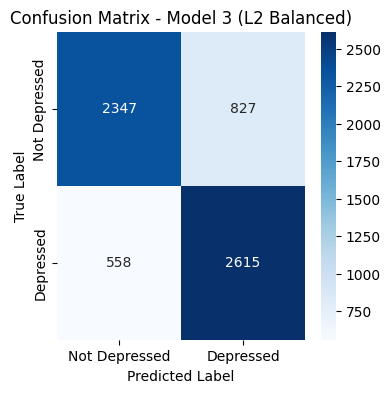

In [6]:
# PART 1: TRAIN AND EVALUATE MODELS
# ==============================================================================
models_params = {
    "Model 1 (Baseline)": {'solver': 'liblinear', 'C': 1.0},
    "Model 2 (L1 Regularization)": {'solver': 'liblinear', 'C': 0.5, 'penalty': 'l1', 'class_weight': 'balanced'},
    "Model 3 (L2 Balanced)": {'solver': 'liblinear', 'C': 2.0, 'penalty': 'l2', 'class_weight': 'balanced'}
}

results_summary = {}

for name, params in models_params.items():
    print(f"\n=== Training: {name} ===")

    # Initialize and train model
    model = LogisticRegression(**params, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # Print metrics horizontally
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f} | AUC: {auc_score:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Save results
    results_summary[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc_score,
        'Confusion_Matrix': cm,
        'y_pred_proba': y_pred_proba
    }

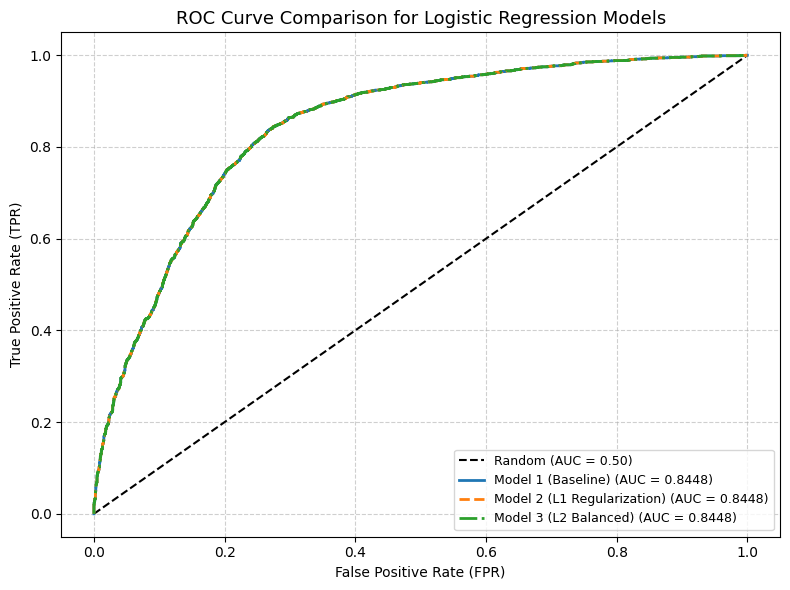

In [7]:
# PART 2: ROC CURVE COMPARISON
# ======================================================================
plt.figure(figsize=(8,6))
plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.50)')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
linestyles = ['-', '--', '-.']

for (name, res), color, ls in zip(results_summary.items(), colors, linestyles):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.title('ROC Curve Comparison for Logistic Regression Models', fontsize=13)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right", fontsize=9)
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [8]:
# PART 3: K-FOLD CROSS-VALIDATION ON BEST MODEL
# ==============================================================================
best_model_name = max(results_summary, key=lambda x: results_summary[x]['AUC'])
best_model = LogisticRegression(**models_params[best_model_name], random_state=42)

print(f"\nK-FOLD CROSS-VALIDATION (5-Fold) on Best Model: {best_model_name}")
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'recall', 'roc_auc']

for score_type in scoring:
    cv_results = cross_val_score(best_model, X_full, y_full, cv=kfold, scoring=score_type, n_jobs=-1)
    print(f"{score_type.upper():<8}: Mean={cv_results.mean():.4f} | Std={cv_results.std():.4f}")


K-FOLD CROSS-VALIDATION (5-Fold) on Best Model: Model 1 (Baseline)
ACCURACY: Mean=0.7762 | Std=0.0035
F1      : Mean=0.7844 | Std=0.0030
RECALL  : Mean=0.8144 | Std=0.0029
ROC_AUC : Mean=0.8427 | Std=0.0055


In [ ]:
# PART 4: FINAL SUMMARY
# ==============================================================================
print("\n=== Final Model Comparison ===")
for name, res in results_summary.items():
    print(f"{name:<25}: Accuracy={res['Accuracy']:.4f} | Precision={res['Precision']:.4f} | Recall={res['Recall']:.4f} | F1={res['F1-Score']:.4f} | AUC={res['AUC']:.4f}")

print(f"\nBest Model: {best_model_name} with highest AUC={results_summary[best_model_name]['AUC']:.4f}")


=== Final Model Comparison ===
Model 1 (Baseline)       : Accuracy=0.7816 | Precision=0.7595 | Recall=0.8241 | F1=0.7905 | AUC=0.8448
Model 2 (L1 Regularization): Accuracy=0.7818 | Precision=0.7596 | Recall=0.8245 | F1=0.7907 | AUC=0.8448
Model 3 (L2 Balanced)    : Accuracy=0.7818 | Precision=0.7597 | Recall=0.8241 | F1=0.7906 | AUC=0.8448

Best Model: Model 1 (Baseline) with highest AUC=0.8448
